In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime 

df = pd.read_csv("Filtered_TitleV_Permits.csv")



In [2]:
# Parse dates 
df["Date Received"] = pd.to_datetime(df["Date Received"], errors="coerce")
df["Date Disposed"] = pd.to_datetime(df["Date Disposed"], errors="coerce")
df["Date Expires"] = pd.to_datetime(df["Date Expires"], errors="coerce")

In [3]:
# Compute backlog (18 months rounded to 548 days)
today = datetime.now()
df["processing_days"] = (df["Date Disposed"] - df["Date Received"]).dt.days
df["backlogged"] = (
    (df["processing_days"] > 548) | 
    (df.loc[df["Date Disposed"].isna(), "Date Expires"] < today)
)
df["Disposition Year"] = df["Date Disposed"].dt.year
df.head()


,Region,County,Municipality,Client,Site Name,Site ID,PF Name,PF ID,Active Facility,Application Type,Permit Type,General Permit Type,Disposition Code,Date Received,Date Disposed,Date Expires,Permit Hyperlink,processing_days,backlogged,Disposition Year
0,Northcentral,Bradford,Asylum Township,HAMILTON LIBERTY LLC,HAMILTON LIBERTY LLC,753377,HAMILTON LIBERTY LLC/HAMILTON LIBERTY LLC,745923,Y,Renewal,Title V Operating Permit,NaN,ISSU,2022-10-19,2023-10-16,2028-10-15,1414543[08-00045]_Issued_v1.pdf,362,False,2023
1,Northcentral,Bradford,Sayre Borough,RYNONE MFG CORP,RYNONE MFG,2854,RYNONE MFG CORP/SAYRE PLT,3850,Y,Renewal,Title V Operating Permit,NaN,ISSU,2020-11-06,2021-05-05,2026-05-04,1332891[08-00004]_Issued_v1.pdf,180,False,2021
2,Northcentral,Bradford,West Burlington Township,NORTHERN TIER SWA,BRADFORD CNTY LDFL 2,242356,NTSWA/BRADFORD CNTY LDFL 101243,510005,Y,Renewal,Title V Operating Permit,NaN,ISSU,2020-07-23,2021-09-16,2026-09-15,1322152[08-00017]_Issued_v1.pdf,420,False,2021
3,Northcentral,Centre,State College Borough,PA STATE UNIV,PENN STATE UNIVERSITY PARK,545486,PA STATE UNIV/UNIV PARK CAMPUS,256457,Y,Renewal,Title V Operating Permit,NaN,ISSU,2024-01-23,2025-08-28,2030-08-27,1469224[14-00003]_Issued_v1.pdf,583,True,2025
4,Northcentral,Clearfield,Bradford Township,SHAWVILLE POWER LLC,SHAWVILLE GENERATING STA,244416,SHAWVILLE POWER LLC/SHAWVILLE GEN STA,249235,Y,Renewal,Title V Operating Permit,NaN,ISSU,2023-02-21,2024-07-30,2029-07-29,1428411[17-00001]_Issued_v1.pdf,525,False,2024


In [4]:
# Aggregate data by Year AND Region
regional_backlog = (
    df[df["backlogged"]]
    .dropna(subset=["Disposition Year", "Region"])
    .groupby(["Disposition Year", "Region"])
    .size()
    .unstack(fill_value=0) # This turns regions into individual columns for plotting
)
regional_backlog.head()


Region,Northcentral,Northeast,Northwest,Southcentral,Southeast,Southwest
Disposition Year,,,,,,
1997,0,0,1,0,0,0
1999,1,0,0,0,0,0
2018,0,1,0,0,0,0
2020,0,0,1,0,1,1
2021,0,0,0,0,1,2


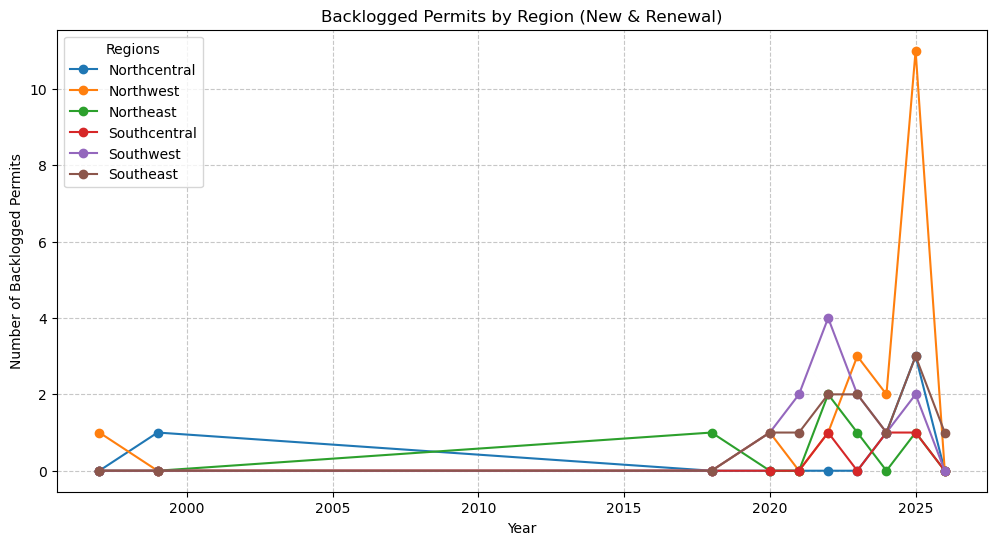

In [5]:
# Classify backlogged permits by Region
regions = ["Northcentral", "Northwest", "Northeast", "Southcentral", "Southwest", "Southeast"]

plt.figure(figsize=(12, 6))
for region in regions:
    if region in regional_backlog.columns:
        plt.plot(regional_backlog.index, regional_backlog[region], marker='o', label=region)

# Visualize line chart 
plt.title("Backlogged Permits by Region (New & Renewal)")
plt.xlabel("Year")
plt.ylabel("Number of Backlogged Permits")
plt.legend(title="Regions")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [6]:
# Interacticve graph - Clickable points in order to see the details of the backlogged permits for that year and region
# The clicked region in the legend is the only one dispayed in the graph, while the others are hidden. 
# This allows users to focus on specific regions and analyze their backlog trends over time.
import plotly.express as px
import plotly.graph_objects as go
import anywidget
import pandas as pd
from IPython.display import display


fig = px.line(
    regional_backlog.reset_index(),
    x="Disposition Year",
    y=regions,
    markers=True,
    title="Backlogged Permits by Region (New & Renewal)",
    labels={"variable": "Region", "Disposition Year": "Year", "value": "Number of Backlogged Permits"},
    template="simple_white"
)
fig.update_layout(legend_title_text="Regions",
                  hovermode="x unified",
                  font = dict(family="Inter, Arial, sans-serif", size=12, color="#0072bc"), # company primary yellow blue for labels
                  legend=dict(itemclick="toggleothers", 
                              itemdoubleclick="toggle",
                              orientation="h",
                              y=1.1)) 
fig.show()

# fig = go.FigureWidget(fig)

# display(fig)


# table_output = pd.DataFrame(columns=["Region", "Year", "Backlogged Permits"])
# display(table_output)
# def update_table(trace, points, selector):

#     if points.point_inds:
#         idx = points.point_inds[0]

#         region = trace.name
#         year = trace.x[idx]
#         permits = trace.y[idx]

#         table = pd.DataFrame({
#             "Region": [region],
#             "Year": [year],
#             "Backlogged Permits": [permits]
#         })

#         display(table)

# for trace in fig.data:
#     trace.on_click(update_table)




In [7]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Styling ────────────────────────────────────────────────────────────────────
display(HTML("""
<style>
  .detail-panel {
    font-family: 'Inter', Arial, sans-serif;
    font-size: 12px;
    color: #0072bc;
    margin-top: 12px;
  }
  .detail-panel h4 {
    margin: 0 0 8px 0;
    font-size: 13px;
    color: #005a96;
    border-bottom: 2px solid #0072bc;
    padding-bottom: 4px;
  }
  .detail-table {
    width: 100%;
    border-collapse: collapse;
    font-size: 11px;
  }
  .detail-table th {
    background: #0072bc;
    color: white;
    padding: 5px 8px;
    text-align: left;
    white-space: nowrap;
  }
  .detail-table td {
    padding: 4px 8px;
    border-bottom: 1px solid #d0e4f5;
  }
  .detail-table tr:nth-child(even) td { background: #f0f7ff; }
  .detail-table tr:hover td { background: #d0e4f5; }
  .detail-panel .meta {
    font-size: 11px;
    color: #888;
    margin-bottom: 6px;
  }
  .no-selection {
    color: #aaa;
    font-style: italic;
    margin-top: 16px;
    font-family: 'Inter', Arial, sans-serif;
    font-size: 12px;
  }
</style>
"""))

# ── Build the FigureWidget ─────────────────────────────────────────────────────
_fig = px.line(
    regional_backlog.reset_index(),
    x="Disposition Year",
    y=regions,
    markers=True,
    title="Backlogged Permits by Region (New & Renewal)",
    labels={
        "variable": "Region",
        "Disposition Year": "Year",
        "value": "Number of Backlogged Permits"
    },
    template="simple_white"
)
_fig.update_layout(
    legend_title_text="Regions",
    hovermode="x unified",
    font=dict(family="Inter, Arial, sans-serif", size=12, color="#0072bc"),
    legend=dict(
        itemclick="toggleothers",
        itemdoubleclick="toggle",
        orientation="h",
        y=1.1
    )
)

fig = go.FigureWidget(_fig)

# ── Detail panel widget ────────────────────────────────────────────────────────
detail_output = widgets.HTML(
    value='<p class="no-selection">🖱️ Click any point on the chart to see permit details.</p>'
)

# Columns to display in the detail table
DETAIL_COLS = [
    "Region", "County", "Municipality", "Client", "Site Name", "Site ID",
    "PF Name", "PF ID", "Active Facility", "Application Type", "Permit Type",
    "General Permit Type", "Disposition Code",
    "Date Received", "Date Disposed", "Date Expires", "Permit Hyperlink"
]

def build_table_html(df, region, year):
    """Render a styled HTML table for the clicked point."""
    if df.empty:
        return f'<div class="detail-panel"><p>No records found for <b>{region}</b> in <b>{year}</b>.</p></div>'

    # Only keep columns that exist in df
    cols = [c for c in DETAIL_COLS if c in df.columns]
    subset = df[cols].copy()

    # Make Permit Hyperlink clickable if present
    if "Permit Hyperlink" in subset.columns:
        subset["Permit Hyperlink"] = subset["Permit Hyperlink"].apply(
            lambda v: f'<a href="{v}" target="_blank">View</a>' if pd.notna(v) and str(v).startswith("http") else (v or "")
        )

    rows_html = ""
    for _, row in subset.iterrows():
        cells = "".join(f"<td>{'' if pd.isna(v) else v}</td>" for v in row)
        rows_html += f"<tr>{cells}</tr>"

    headers = "".join(f"<th>{c}</th>" for c in cols)

    return f"""
    <div class="detail-panel">
      <h4>📋 {region} &mdash; {int(year)}</h4>
      <p class="meta">{len(df)} permit(s) found</p>
      <div style="overflow-x:auto; max-height:300px; overflow-y:auto;">
        <table class="detail-table">
          <thead><tr>{headers}</tr></thead>
          <tbody>{rows_html}</tbody>
        </table>
      </div>
    </div>
    """

# ── Raw permit-level data ──────────────────────────────────────────────────────

# Gets the active region from the user selection in the legend.
def single_region_active():
    """Returns the name of the active trace if exactly one is visible, else None."""
    visible_traces = [t for t in fig.data if t.visible is True or t.visible is None]
    # After legend "toggleothers" click, others get visible=False or 'legendonly'
    truly_visible = [
        t for t in fig.data
        if t.visible not in (False, "legendonly")
    ]
    return truly_visible[0].name if len(truly_visible) == 1 else None

def on_click(trace, points, selector):
    if not points.point_inds:
        return

    # ── Guard: only respond if user has isolated a single region ──────────
    active_region = single_region_active()
    if active_region is None:
        detail_output.value = (
            '<p class="no-selection">'
            '👆 Click a <b>region in the legend</b> to isolate it, '
            'then click a point to see permit details.'
            '</p>'
        )
        return
    # ──────────────────────────────────────────────────────────────────────

    idx    = points.point_inds[0]
    region = trace.name
    year   = trace.x[idx]

    mask = (
        (df["Region"] == region) &
        (df["Disposition Year"] == year) &
        (df["backlogged"] == True)
    )
    filtered = df[mask]

    detail_output.value = build_table_html(filtered, region, year)

for trace in fig.data:
    trace.on_click(on_click)

# ── Layout ────────────────────────────────────────────────────────────────────
dashboard = widgets.VBox(
    [fig, detail_output],
    layout=widgets.Layout(width="100%")
)
display(dashboard)



    'data': [{'hovertemplate': ('Region=Northcentral<br>Year=%{' ... 'ed Permits…

In [8]:
regional_backlog.head()
print(df.columns.tolist())
print(df.head(2))


['Region', 'County', 'Municipality', 'Client', 'Site Name', 'Site ID', 'PF Name', 'PF ID', 'Active Facility', 'Application Type', 'Permit Type', 'General Permit Type', 'Disposition Code', 'Date Received', 'Date Disposed', 'Date Expires', 'Permit Hyperlink', 'processing_days', 'backlogged', 'Disposition Year']
         Region    County     Municipality                Client  \
0  Northcentral  Bradford  Asylum Township  HAMILTON LIBERTY LLC   
1  Northcentral  Bradford    Sayre Borough       RYNONE MFG CORP   

              Site Name  Site ID                                    PF Name  \
0  HAMILTON LIBERTY LLC   753377  HAMILTON LIBERTY LLC/HAMILTON LIBERTY LLC   
1            RYNONE MFG     2854                  RYNONE MFG CORP/SAYRE PLT   

    PF ID Active Facility Application Type               Permit Type  \
0  745923               Y          Renewal  Title V Operating Permit   
1    3850               Y          Renewal  Title V Operating Permit   

   General Permit Type Dispos

In [ ]:
# Heatmap - Backlogged Permits by Region and Year

import plotly.express as px

heatmap_data = regional_backlog.T

fig_heatmap = px.imshow(
    heatmap_data,
    labels=dict(
        x="Disposition Year",
        y="Region",
        color="Backlogged Permits"
    ),
    title="Heatmap of Backlogged Permits by Region and Year",
    aspect="auto",
    color_continuous_scale="Blues"
)

fig_heatmap.update_layout(
    font=dict(
        family="Inter, Arial, sans-serif",
        size=12,
        color="#0072bc"
    )
)

fig_heatmap.show()

In [ ]:
# Bar Chart - Backlogged Permits by Region

import plotly.express as px

# Aggregate total backlog by region
region_totals = (
    df[df["backlogged"]]
    .groupby("Region")
    .size()
    .reset_index(name="Total Backlogged Permits")
)

# Sort descending
region_totals = region_totals.sort_values(
    "Total Backlogged Permits", ascending=False
)

fig_ranked = px.bar(
    region_totals,
    x="Region",
    y="Total Backlogged Permits",
    color="Region",
    title="Total Backlogged Permits by Region (Ranked)",
    template="simple_white"
)

fig_ranked.update_layout(
    font=dict(
        family="Inter, Arial, sans-serif",
        size=12,
        color="#0072bc"
    ),
    xaxis_title="Region",
    yaxis_title="Number of Backlogged Permits",
    showlegend=False
)

fig_ranked.show()

In [ ]:
# Bar Chart - Backlogged Permits by Year

import plotly.express as px

# Count backlogged permits per year
backlog_by_year = (
    df[df["backlogged"]]
    .dropna(subset=["Disposition Year"])
    .groupby("Disposition Year")
    .size()
    .reset_index(name="Backlogged Permits")
    .sort_values("Disposition Year")
)

fig_year_bar = px.bar(
    backlog_by_year,
    x="Disposition Year",
    y="Backlogged Permits",
    title="Backlogged Permits by Year",
    template="simple_white"
)

fig_year_bar.update_layout(
    font=dict(
        family="Inter, Arial, sans-serif",
        size=12,
        color="#0072bc"
    ),
    xaxis_title="Disposition Year",
    yaxis_title="Number of Backlogged Permits"
)

fig_year_bar.show()

In [ ]:
# Facted Line Chart - Each Region Separate

facet_data = regional_backlog.reset_index().melt(
    id_vars="Disposition Year",
    var_name="Region",
    value_name="Backlogged Permits"
)

fig_facet = px.line(
    facet_data,
    x="Disposition Year",
    y="Backlogged Permits",
    facet_col="Region",
    facet_col_wrap=3,
    title="Backlogged Permits by Region (Faceted)",
    template="simple_white"
)

fig_facet.update_layout(
    font=dict(family="Inter, Arial, sans-serif", size=12, color="#0072bc")
)

fig_facet.show()